In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import seaborn as sns
!pip install python-louvain
import community as community_louvain


In [2]:

file_path = "../data/train.txt"
triples = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:  # skip empty lines
            head, relation, tail = line.split()
            triples.append((head, relation, tail))
print(f"Total triples loaded: {len(triples)}")

Total triples loaded: 13821


In [3]:
df = pd.DataFrame(triples, columns=["head", "relation", "tail"])
entities = pd.unique(df[["head", "tail"]].values.ravel())
relations = pd.unique(df["relation"].values.ravel())
unique_nodes = pd.unique(df[["head", "tail"]].values.ravel())
unique_nodes = unique_nodes.tolist()
# Count occurrences of each relation
relation_counts = df["relation"].value_counts()

# Convert to dictionary
relation_count_dict = relation_counts.to_dict()
relation_stats_df = relation_counts.reset_index()
relation_stats_df.columns = ["relation", "count"]


In [4]:
G = nx.MultiDiGraph()
for _, row in df.iterrows():
    G.add_edge(
        row["head"],
        row["tail"],
        relation=row["relation"]
    )
print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")


Graph has 1316 nodes and 13821 edges.


In [5]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())


Number of nodes: 1316
Number of edges: 13821


In [6]:
# Louvain expects an undirected graph
G_undirected = G.to_undirected()

# Compute best partition
partition = community_louvain.best_partition(G_undirected)


In [7]:
community_df = pd.DataFrame(
    partition.items(),
    columns=["person", "community"]
)

community_df.head()


,person,community
0,olivia0,0
1,selina10,0
2,isabella11,0
3,oskar24,0
4,adam9,0


In [8]:
num_communities = community_df["community"].nunique()
print("Number of detected communities:", num_communities)


Number of detected communities: 50


In [9]:
community_sizes = (
    community_df
    .groupby("community")
    .size()
    .sort_values(ascending=False)
)

community_sizes


community
0     27
5     27
13    27
7     27
31    27
30    27
46    27
48    27
40    27
44    27
35    27
38    27
20    27
18    27
27    27
33    27
1     26
3     26
17    26
16    26
15    26
14    26
12    26
11    26
10    26
9     26
2     26
8     26
6     26
4     26
25    26
24    26
19    26
21    26
32    26
26    26
28    26
29    26
22    26
23    26
37    26
34    26
41    26
39    26
36    26
42    26
45    26
43    26
47    26
49    26
dtype: int64

## Modularity

**Modularity** is a measure of the quality of a network's division into communities, quantifying how well-separated communities are from one another.

**Formula:**
$$Q = \frac{1}{2m} \sum_{i,j} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

where:
- $m$ = total number of edges in the network
- $A_{ij}$ = adjacency matrix (1 if edge exists between nodes $i$ and $j$, else 0)
- $k_i$, $k_j$ = degrees of nodes $i$ and $j$
- $\frac{k_i k_j}{2m}$ = expected number of edges between $i$ and $j$ in a random network
- $\delta(c_i, c_j)$ = 1 if nodes $i$ and $j$ are in the same community, else 0

**Key Properties:**
- **Range:** -0.5 to 1.0 (typically 0.3 to 0.7 for real networks)
- **Q > 0.3:** Significant community structure detected
- **Q > 0.7:** Very strong community structure (rare)
- **Q ≈ 0:** No better than random partition
- **Q < 0:** Fewer within-community edges than expected by chance

**Interpretation:**
Modularity compares actual within-community edges to what would be expected in a random network. Higher values indicate that nodes within communities are more densely connected to each other than to nodes in other communities.

**Limitations:**
- Resolution limit: may miss small communities in large networks
- Degeneracy: multiple partitions can have similar high modularity
- Favors equal-sized communities

In [10]:
modularity = community_louvain.modularity(
    partition,
    G_undirected
)

print("Louvain Modularity Score:", modularity)


Louvain Modularity Score: 0.979357287883554


In [11]:
nx.set_node_attributes(G, partition, "community")


/home/phanindra/Desktop/SEM4/Precog/Precog_Task/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


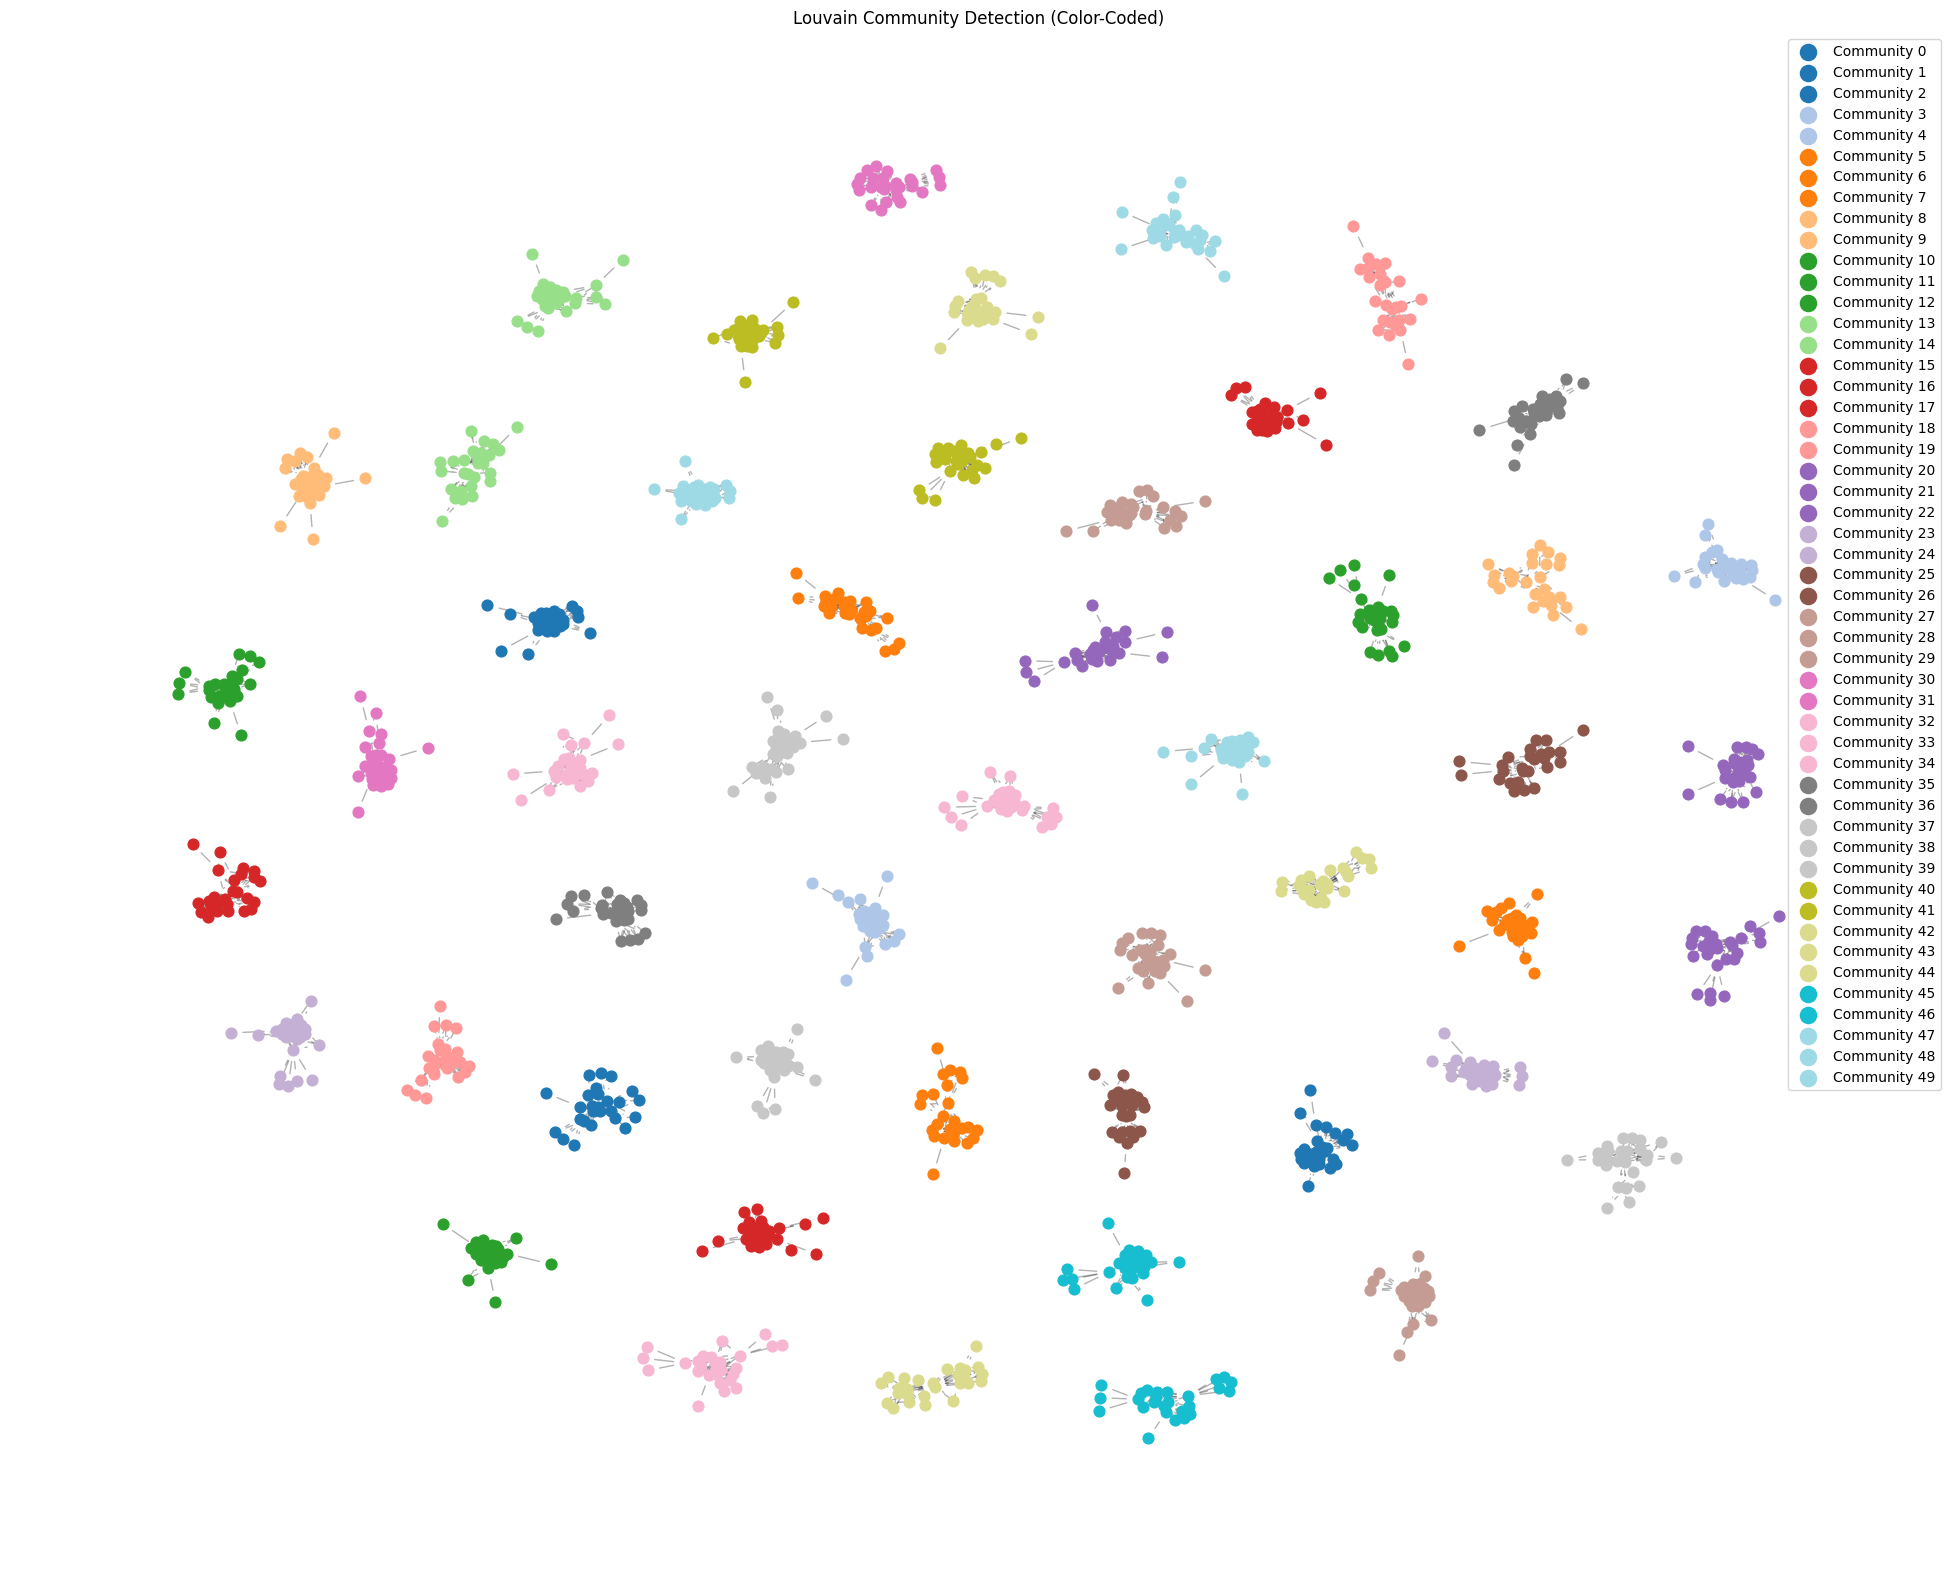

In [12]:
# plt.figure(figsize=(10, 10))

# pos = nx.spring_layout(G_undirected, seed=42)
# communities = list(set(partition.values()))

# for comm in communities:
#     nodes = [n for n in G_undirected.nodes() if partition[n] == comm]
#     nx.draw_networkx_nodes(G_undirected, pos, nodes, node_size=40)

# nx.draw_networkx_edges(G_undirected, pos, alpha=0.3)
# plt.title("Louvain Community Detection")
# plt.axis("off")
# plt.show()
plt.figure(figsize=(25, 20))

# Layout (keep fixed for reproducibility)
pos = nx.spring_layout(G_undirected, seed=42)

# Unique Louvain communities
communities = list(set(partition.values()))

# Generate distinct colors
colors = plt.cm.tab20(np.linspace(0, 1, len(communities)))

# Map community → color
community_color_map = {
    comm: colors[i]
    for i, comm in enumerate(communities)
}

# Draw nodes community-wise
for comm in communities:
    nodes = [
        n for n in G_undirected.nodes()
        if partition[n] == comm
    ]
    
    nx.draw_networkx_nodes(
        G_undirected,
        pos,
        nodelist=nodes,
        node_color=[community_color_map[comm]],
        node_size=60,
        label=f"Community {comm}"
    )

# Draw edges
nx.draw_networkx_edges(
    G_undirected,
    pos,
    alpha=0.3,
    width=1
)

plt.title("Louvain Community Detection (Color-Coded)")
plt.axis("off")
plt.legend(markerscale=1.5)
plt.show()

In [13]:
import itertools
G_undirected = G.to_undirected()
from networkx.algorithms.community import girvan_newman

communities_generator = girvan_newman(G_undirected)


In [14]:
level_1_communities = next(communities_generator)
level_2_communities = next(communities_generator)
level_3_communities = next(communities_generator)


In [15]:
selected_communities = level_2_communities
len(selected_communities)


52

In [16]:
girvan_partition = {}

for idx, community in enumerate(selected_communities):
    for person in community:
        girvan_partition[person] = idx

girvan_df = pd.DataFrame(
    girvan_partition.items(),
    columns=["person", "community"]
)

girvan_df.head()


,person,community
0,oskar24,0
1,natalie13,0
2,vincent21,0
3,nico4,0
4,david20,0


In [17]:
girvan_sizes = (
    girvan_df
    .groupby("community")
    .size()
    .sort_values(ascending=False)
)

girvan_sizes


community
14    27
19    27
8     27
6     27
41    27
49    27
28    27
32    27
35    27
31    27
47    27
45    27
33    27
21    27
11    26
3     26
7     26
9     26
2     26
0     26
34    26
18    26
16    26
17    26
12    26
13    26
10    26
15    26
4     26
5     26
25    26
24    26
27    26
26    26
22    26
20    26
46    26
30    26
29    26
23    26
42    26
36    26
38    26
37    26
50    26
43    26
40    26
44    26
51    26
48    26
1      1
39     1
dtype: int64

In [18]:
from networkx.algorithms.community.quality import modularity

girvan_communities_list = list(selected_communities)

girvan_modularity = modularity(
    G_undirected,
    girvan_communities_list
)

print("Girvan–Newman Modularity:", girvan_modularity)


Girvan–Newman Modularity: 0.9790960743801653


In [19]:
nx.set_node_attributes(G, girvan_partition, "girvan_community")


/home/phanindra/Desktop/SEM4/Precog/Precog_Task/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


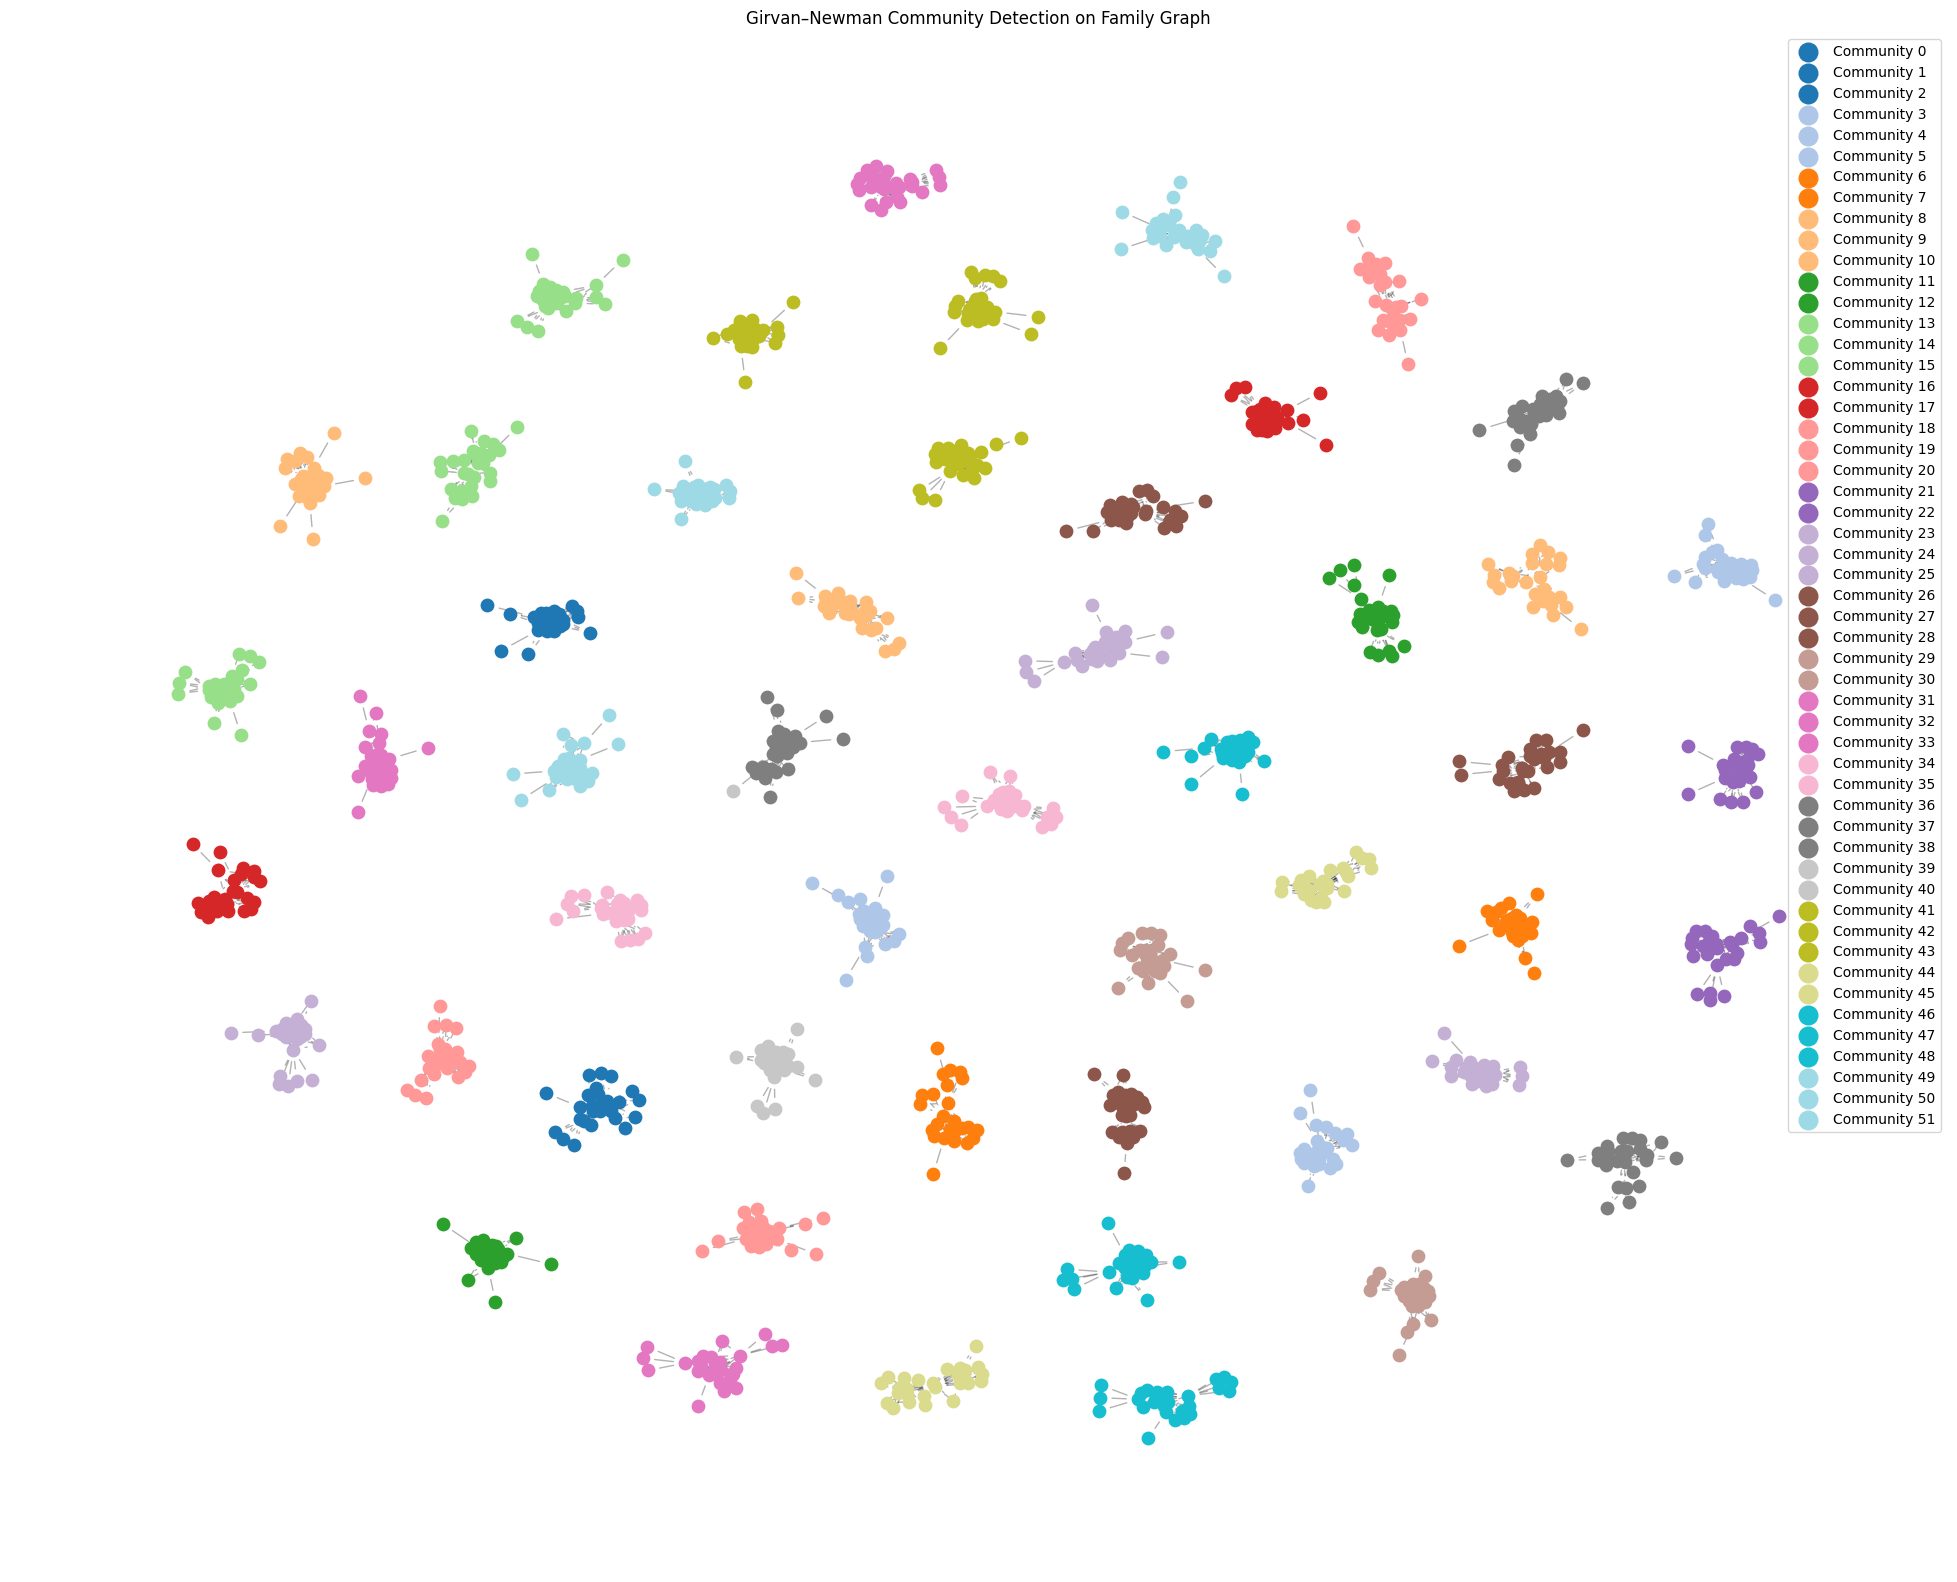

In [20]:
# Unique community IDs
community_ids = list(set(girvan_partition.values()))

# Assign a color to each community
colors = plt.cm.tab20(np.linspace(0, 1, len(community_ids)))

community_color_map = {
    comm_id: colors[i]
    for i, comm_id in enumerate(community_ids)
}
pos = nx.spring_layout(G_undirected, seed=42)
plt.figure(figsize=(25, 20))

for comm_id in community_ids:
    nodes_in_comm = [
        node for node in G_undirected.nodes()
        if girvan_partition.get(node) == comm_id
    ]
    
    nx.draw_networkx_nodes(
        G_undirected,
        pos,
        nodelist=nodes_in_comm,
        node_color=[community_color_map[comm_id]],
        node_size=80,
        label=f"Community {comm_id}"
    )
nx.draw_networkx_edges(
    G_undirected,
    pos,
    alpha=0.3,
    width=1
)
plt.title("Girvan–Newman Community Detection on Family Graph")
plt.axis("off")
plt.legend(markerscale=1.5)
plt.show()


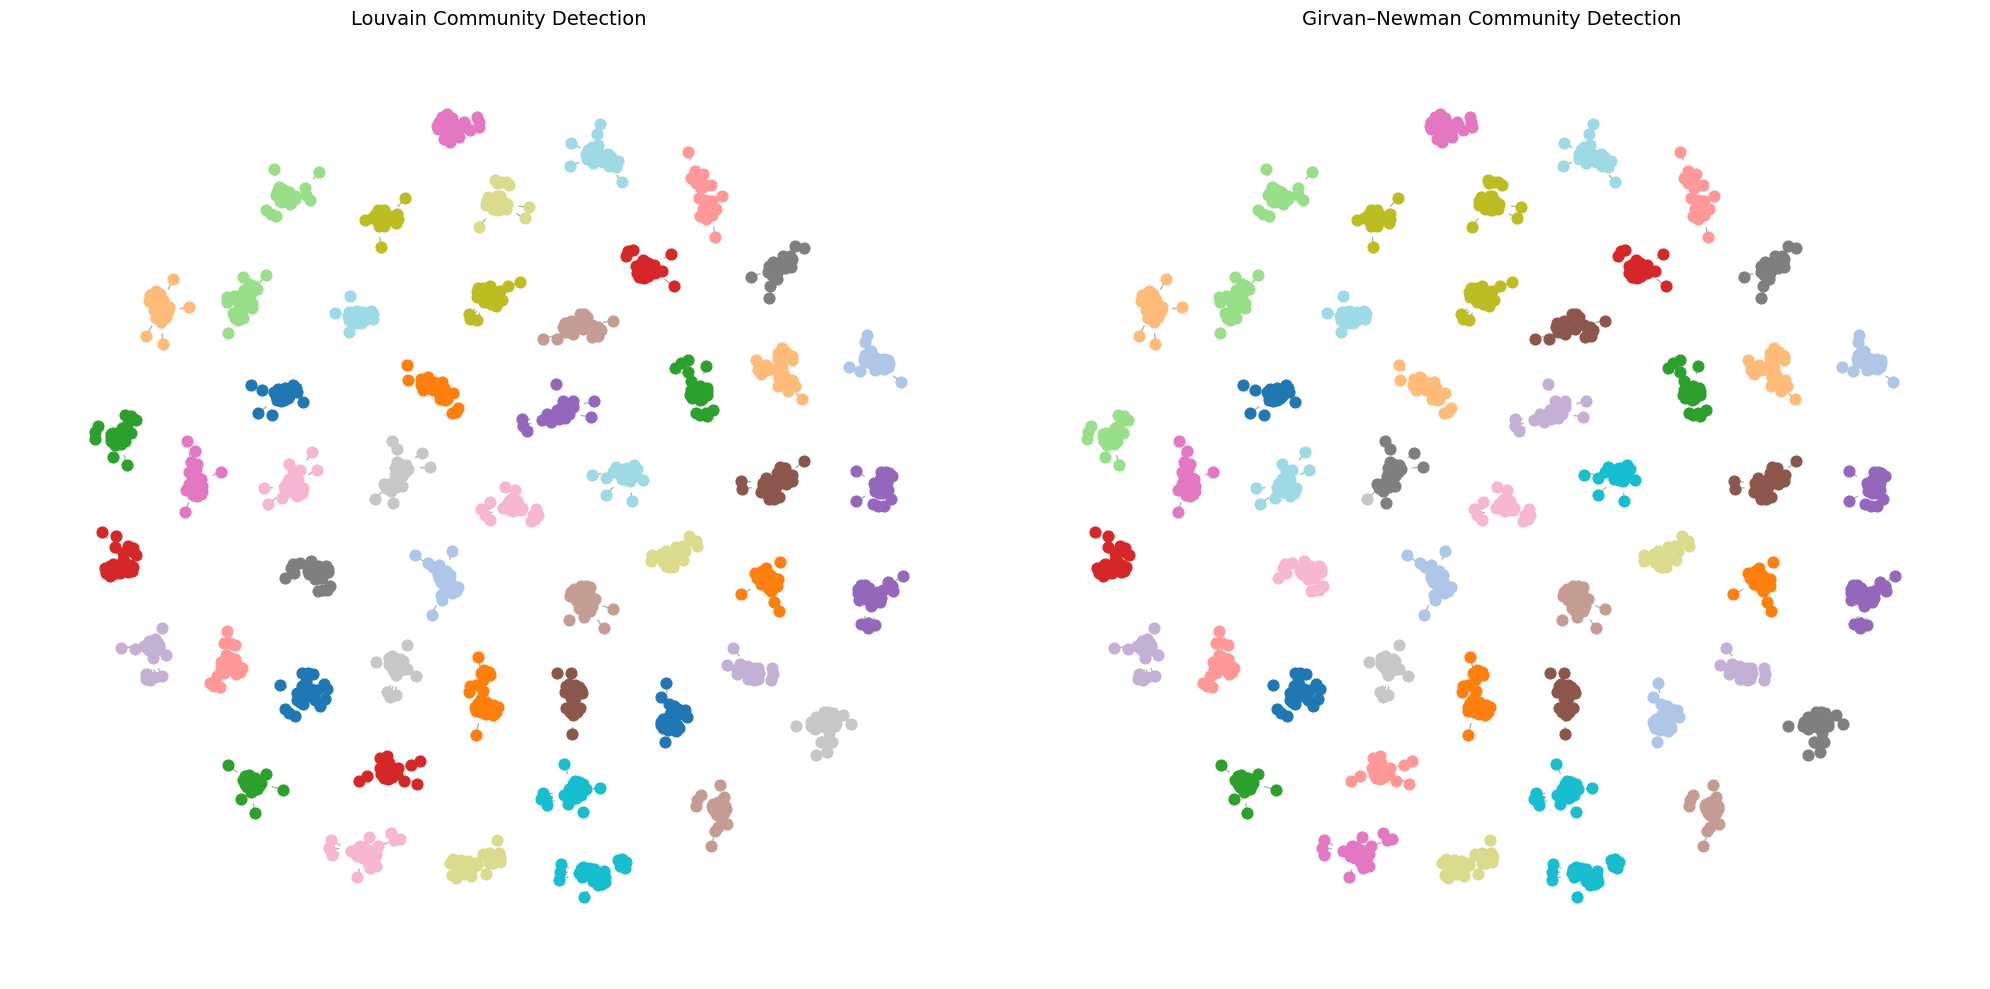

In [21]:
# comparison of both the algos
# Louvain colors
louvain_comms = list(set(partition.values()))
louvain_colors = plt.cm.tab20(np.linspace(0, 1, len(louvain_comms)))
louvain_color_map = dict(zip(louvain_comms, louvain_colors))

# Girvan–Newman colors
girvan_comms = list(set(girvan_partition.values()))
girvan_colors = plt.cm.tab20(np.linspace(0, 1, len(girvan_comms)))
girvan_color_map = dict(zip(girvan_comms, girvan_colors))

pos = nx.spring_layout(G_undirected, seed=42)
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].set_title("Louvain Community Detection", fontsize=14)

for comm in louvain_comms:
    nodes = [
        node for node in G_undirected.nodes()
        if partition[node] == comm
    ]
    
    nx.draw_networkx_nodes(
        G_undirected,
        pos,
        nodelist=nodes,
        node_color=[louvain_color_map[comm]],
        node_size=60,
        ax=axes[0]
    )

nx.draw_networkx_edges(
    G_undirected,
    pos,
    alpha=0.3,
    ax=axes[0]
)

axes[0].axis("off")

axes[1].set_title("Girvan–Newman Community Detection", fontsize=14)

for comm in girvan_comms:
    nodes = [
        node for node in G_undirected.nodes()
        if girvan_partition[node] == comm
    ]
    
    nx.draw_networkx_nodes(
        G_undirected,
        pos,
        nodelist=nodes,
        node_color=[girvan_color_map[comm]],
        node_size=60,
        ax=axes[1]
    )

nx.draw_networkx_edges(
    G_undirected,
    pos,
    alpha=0.3,
    ax=axes[1]
)

axes[1].axis("off")
plt.tight_layout()
plt.show()


## Conductance

**Conductance** measures the quality of a community by quantifying how well-separated it is from the rest of the graph.

**Formula:**
$$\text{Conductance}(C) = \frac{\text{Cut}(C)}{\text{Volume}(C)}$$

where:
- $\text{Cut}(C)$ = number of edges leaving the community $C$
- $\text{Volume}(C)$ = sum of degrees of all nodes in community $C$

**Key Properties:**
- **Range:** 0 to 1
- **Lower is better:** indicates a more cohesive, well-separated community
- $\text{Conductance} = 0$ → isolated community (no external edges)
- $\text{Conductance} = 1$ → poorly defined community (all edges go outside)

**Interpretation:**
- **Low conductance (< 0.3):** Strong community with dense internal connections, few external edges
- **High conductance (> 0.6):** Weak community boundary, many connections to outside nodes
- Balances cut size with community size, avoiding bias toward small communities

In [22]:
def conductance(G, community_nodes):
    """
    Conductance of a single community
    """
    cut_edges = 0
    volume = 0

    for node in community_nodes:
        for neighbor in G.neighbors(node):
            if neighbor not in community_nodes:
                cut_edges += 1
        volume += G.degree(node)

    if volume == 0:
        return 0

    return cut_edges / volume


## Internal Density

**Internal density** measures how tightly connected the nodes within a community are, representing the cohesiveness of the community structure.

**Formula:**
$$\text{Internal Density}(C) = \frac{|E_{\text{internal}}|}{\binom{|C|}{2}} = \frac{2 \cdot |E_{\text{internal}}|}{|C| \cdot (|C| - 1)}$$

where:
- $|E_{\text{internal}}|$ = number of edges between nodes within community $C$
- $|C|$ = number of nodes in community $C$
- Denominator = maximum possible edges in a complete graph of size $|C|$

**Key Properties:**
- **Range:** 0 to 1
- **Higher is better:** indicates more densely connected community
- $\text{Density} = 1$ → complete subgraph (clique), all nodes connected
- $\text{Density} = 0$ → no internal connections

**Interpretation:**
- **High density (> 0.6):** Highly cohesive community with many internal relationships
- **Medium density (0.3-0.6):** Moderately connected group
- **Low density (< 0.3):** Loosely connected community, may need restructuring
- Complements conductance: good communities have high internal density and low conductance

In [23]:
def internal_density(G, community_nodes):
    """
    Internal density of a single community
    """
    subgraph = G.subgraph(community_nodes)
    n = subgraph.number_of_nodes()

    if n <= 1:
        return 0

    m = subgraph.number_of_edges()
    return (2 * m) / (n * (n - 1))


In [24]:
louvain_metrics = []

for comm_id in set(partition.values()):
    nodes = {n for n in G_undirected.nodes() if partition[n] == comm_id}

    louvain_metrics.append({
        "algorithm": "Louvain",
        "community": comm_id,
        "size": len(nodes),
        "conductance": conductance(G_undirected, nodes),
        "internal_density": internal_density(G_undirected, nodes)
    })

louvain_metrics_df = pd.DataFrame(louvain_metrics)
louvain_metrics_df.head()


,algorithm,community,size,conductance,internal_density
0,Louvain,0,27,0.0,0.586895
1,Louvain,1,26,0.0,0.329231
2,Louvain,2,26,0.0,0.458462
3,Louvain,3,26,0.0,0.464615
4,Louvain,4,26,0.0,0.498462


In [25]:
girvan_metrics = []

for idx, community_nodes in enumerate(selected_communities):
    nodes = set(community_nodes)

    girvan_metrics.append({
        "algorithm": "Girvan–Newman",
        "community": idx,
        "size": len(nodes),
        "conductance": conductance(G_undirected, nodes),
        "internal_density": internal_density(G_undirected, nodes)
    })

girvan_metrics_df = pd.DataFrame(girvan_metrics)
girvan_metrics_df.head()


,algorithm,community,size,conductance,internal_density
0,Girvan–Newman,0,26,0.002433,0.630769
1,Girvan–Newman,1,1,1.000000,0.000000
2,Girvan–Newman,2,26,0.000000,0.329231
3,Girvan–Newman,3,26,0.000000,0.458462
4,Girvan–Newman,4,26,0.000000,0.464615


## Analysis 1: Do Communities Correspond to Actual Family Units?

We'll compare detected communities with "ground truth" families (weakly connected components) to see if algorithmic communities match biological/social family structures.

In [26]:
# Identify "ground truth" families using weakly connected components
# These represent actual biological family units

families = list(nx.weakly_connected_components(G))
num_families = len(families)

# Create family membership dictionary
family_membership = {}
for fam_id, family in enumerate(families):
    for person in family:
        family_membership[person] = fam_id

print(f"Number of actual families (weakly connected components): {num_families}")

# Create DataFrame for comparison
family_df = pd.DataFrame(
    family_membership.items(),
    columns=["person", "actual_family"]
)

family_sizes = family_df.groupby("actual_family").size().sort_values(ascending=False)
print(f"\nFamily size statistics:")
print(f"  Mean: {family_sizes.mean():.2f}")
print(f"  Median: {family_sizes.median():.2f}")
print(f"  Min: {family_sizes.min()}")
print(f"  Max: {family_sizes.max()}")

Number of actual families (weakly connected components): 50

Family size statistics:
  Mean: 26.32
  Median: 26.00
  Min: 26
  Max: 27


In [27]:
# Merge all information: actual family, Louvain community, Girvan-Newman community
comparison_df = family_df.copy()
comparison_df = comparison_df.merge(
    community_df, on="person", how="left"
).rename(columns={"community": "louvain_community"})

comparison_df = comparison_df.merge(
    girvan_df, on="person", how="left"
).rename(columns={"community": "girvan_community"})

print("Sample of comparison data:")
print(comparison_df.head(10))
print(f"\nTotal individuals: {len(comparison_df)}")

Sample of comparison data:
       person  actual_family  louvain_community  girvan_community
0     oskar24              0                  0                 0
1   natalie13              0                  0                 0
2   vincent21              0                  0                 0
3       nico4              0                  0                 0
4     david20              0                  0                 0
5  isabella11              0                  0                 0
6     olivia0              0                  0                 0
7      luis14              0                  0                 0
8      lena18              0                  0                 0
9    selina10              0                  0                 0

Total individuals: 1316


## Purity Score

**Purity** is an evaluation metric that measures how well detected communities align with actual known families

**Formula:**
$$\text{Purity} = \frac{1}{N} \sum_{k=1}^{K} \max_{j} |C_k \cap F_j|$$

where:
- $N$ = total number of nodes
- $K$ = number of detected communities
- $C_k$ = set of nodes in detected community $k$
- $F_j$ = set of nodes in ground truth family $j$
- For each community, we count nodes belonging to the most common ground truth label

**Key Properties:**
- **Range:** 0 to 1
- **Higher is better:** indicates communities closely match actual families
- $\text{Purity} = 1$ → perfect alignment (each community contains only one family)
- $\text{Purity} \approx 0$ → poor alignment (communities are mixed)

**Interpretation:**
- **High purity (> 0.8):** Excellent - detected communities are "pure" (homogeneous families)
- **Medium purity (0.5-0.8):** Moderate - some mixing of families within communities
- **Low purity (< 0.5):** Poor - communities contain mixed families
- **Limitation:** Can be high even with many small trivial clusters; doesn't penalize over-segmentation

**In Family Networks:**
Purity measures whether the algorithm successfully grouped family members together without mixing different families in the same community.

In [30]:
# Calculate Purity: measures how "pure" each community is w.r.t. actual families
def calculate_purity(labels_true, labels_pred):
    """
    Purity: % of individuals in each detected community that belong to the same actual family
    Higher = better alignment with families
    """
    confusion = pd.crosstab(labels_pred, labels_true)
    purity = confusion.max(axis=1).sum() / len(labels_true)
    return purity

# Calculate for both algorithms
louvain_purity = calculate_purity(
    comparison_df["actual_family"],
    comparison_df["louvain_community"]
)

girvan_purity = calculate_purity(
    comparison_df["actual_family"],
    comparison_df["girvan_community"]
)

print("Community-Family Correspondence Metrics:")
print("=" * 50)
print(f"Louvain Purity Score: {louvain_purity:.4f}")
print(f"Girvan-Newman Purity Score: {girvan_purity:.4f}")


Community-Family Correspondence Metrics:
Louvain Purity Score: 1.0000
Girvan-Newman Purity Score: 1.0000


## Normalized Mutual Information (NMI) and Adjusted Rand Index (ARI)

### Normalized Mutual Information (NMI)

**NMI** measures the mutual dependence between two clusterings (detected communities vs. ground truth), normalized to the range [0, 1].

**Formula:**
$$\text{NMI}(X, Y) = \frac{2 \cdot I(X; Y)}{H(X) + H(Y)}$$

where:
- $I(X; Y)$ = mutual information between clusterings $X$ and $Y$
- $H(X)$, $H(Y)$ = entropies of clusterings $X$ and $Y$

**Properties:**
- **Range:** 0 to 1
- **NMI = 0:** Clusterings are completely independent
- **NMI = 1:** Perfect agreement between clusterings
- **Symmetric:** NMI(X, Y) = NMI(Y, X)
- Accounts for chance agreement better than purity

---

### Adjusted Rand Index (ARI)

**ARI** measures similarity between two clusterings by counting pairs of elements that are consistently grouped or separated.

**Formula:**
$$\text{ARI} = \frac{\text{RI} - \text{Expected RI}}{\text{Max RI} - \text{Expected RI}}$$

where RI (Rand Index) counts:
- Pairs in same cluster in both clusterings (true positives)
- Pairs in different clusters in both clusterings (true negatives)

**Properties:**
- **Range:** -1 to 1 (typically 0 to 1)
- **ARI = 1:** Perfect agreement
- **ARI = 0:** Random clustering (no better than chance)
- **ARI < 0:** Worse than random
- **Adjusted for chance:** Corrects for random agreement, unlike basic Rand Index

---

### Interpretation Guidelines

| Metric | Excellent | Good | Fair | Poor |
|--------|-----------|------|------|------|
| **NMI** | > 0.9 | 0.7-0.9 | 0.5-0.7 | < 0.5 |
| **ARI** | > 0.9 | 0.7-0.9 | 0.4-0.7 | < 0.4 |

**Both metrics:**
- Higher values indicate better alignment with ground truth
- Account for chance agreement (unlike purity)
- Suitable for comparing different algorithms
- Work with varying numbers of clusters

In [31]:
# Use sklearn metrics for comprehensive evaluation
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

# Normalized Mutual Information (NMI): 0 = independent, 1 = identical
louvain_nmi = normalized_mutual_info_score(
    comparison_df["actual_family"],
    comparison_df["louvain_community"]
)

girvan_nmi = normalized_mutual_info_score(
    comparison_df["actual_family"],
    comparison_df["girvan_community"]
)

# Adjusted Rand Index (ARI): -1 to 1, where 1 = perfect match
louvain_ari = adjusted_rand_score(
    comparison_df["actual_family"],
    comparison_df["louvain_community"]
)

girvan_ari = adjusted_rand_score(
    comparison_df["actual_family"],
    comparison_df["girvan_community"]
)

print("\nAdditional Clustering Quality Metrics:")
print("=" * 50)
print(f"Normalized Mutual Information (0-1, higher better):")
print(f"  Louvain: {louvain_nmi:.4f}")
print(f"  Girvan-Newman: {girvan_nmi:.4f}")
print(f"\nAdjusted Rand Index (-1 to 1, higher better):")
print(f"  Louvain: {louvain_ari:.4f}")
print(f"  Girvan-Newman: {girvan_ari:.4f}")


Additional Clustering Quality Metrics:
Normalized Mutual Information (0-1, higher better):
  Louvain: 1.0000
  Girvan-Newman: 0.9992

Adjusted Rand Index (-1 to 1, higher better):
  Louvain: 1.0000
  Girvan-Newman: 0.9984


In [32]:
# Detailed analysis: Which families are split? Which communities mix families?

# For Louvain: Check if families are split across multiple communities
family_splits_louvain = comparison_df.groupby("actual_family")["louvain_community"].nunique()
split_families_louvain = family_splits_louvain[family_splits_louvain > 1]

print("LOUVAIN ANALYSIS:")
print("=" * 50)
print(f"Families split across multiple communities: {len(split_families_louvain)} / {num_families}")
if len(split_families_louvain) > 0:
    print(f"  Max splits: {family_splits_louvain.max()} communities")
    print(f"  Example split families (family_id: num_communities):")
    for fam_id, num_comms in split_families_louvain.head(5).items():
        fam_size = family_sizes[fam_id]
        print(f"    Family {fam_id}: {fam_size} members split into {num_comms} communities")

# Check if communities contain multiple families
community_mixing_louvain = comparison_df.groupby("louvain_community")["actual_family"].nunique()
mixed_communities_louvain = community_mixing_louvain[community_mixing_louvain > 1]

print(f"\nCommunities mixing multiple families: {len(mixed_communities_louvain)} / {comparison_df['louvain_community'].nunique()}")
if len(mixed_communities_louvain) > 0:
    print(f"  Max families in one community: {community_mixing_louvain.max()}")
    print(f"  Example mixed communities (community_id: num_families):")
    for comm_id, num_fams in mixed_communities_louvain.head(5).items():
        comm_size = community_sizes.loc[comm_id]
        print(f"    Community {comm_id}: {comm_size} members from {num_fams} families")

LOUVAIN ANALYSIS:
Families split across multiple communities: 0 / 50

Communities mixing multiple families: 0 / 50


In [35]:
# Same analysis for Girvan-Newman
family_splits_girvan = comparison_df.groupby("actual_family")["girvan_community"].nunique()
split_families_girvan = family_splits_girvan[family_splits_girvan > 1]

print("\nGIRVAN-NEWMAN ANALYSIS:")
print(f"Families split across multiple communities: {len(split_families_girvan)} / {num_families}")
if len(split_families_girvan) > 0:
    print(f"  Max splits: {family_splits_girvan.max()} communities")
    print(f"  Example split families (family_id: num_communities):")
    for fam_id, num_comms in split_families_girvan.head(5).items():
        fam_size = family_sizes[fam_id]
        print(f"    Family {fam_id}: {fam_size} members split into {num_comms} communities")

community_mixing_girvan = comparison_df.groupby("girvan_community")["actual_family"].nunique()
mixed_communities_girvan = community_mixing_girvan[community_mixing_girvan > 1]

print(f"\nCommunities mixing multiple families: {len(mixed_communities_girvan)} / {comparison_df['girvan_community'].nunique()}")
if len(mixed_communities_girvan) > 0:
    print(f"  Max families in one community: {community_mixing_girvan.max()}")
    print(f"  Example mixed communities (community_id: num_families):")
    for comm_id, num_fams in mixed_communities_girvan.head(5).items():
        comm_size = girvan_sizes.loc[comm_id]
        print(f"    Community {comm_id}: {comm_size} members from {num_fams} families")


GIRVAN-NEWMAN ANALYSIS:
Families split across multiple communities: 2 / 50
  Max splits: 2 communities
  Example split families (family_id: num_communities):
    Family 0: 27 members split into 2 communities
    Family 37: 27 members split into 2 communities

Communities mixing multiple families: 0 / 52



Comparative Summary:
    Algorithm  Purity     NMI      ARI  Modularity
      Louvain     1.0 1.00000 1.000000    0.979357
Girvan-Newman     1.0 0.99917 0.998407    0.979096


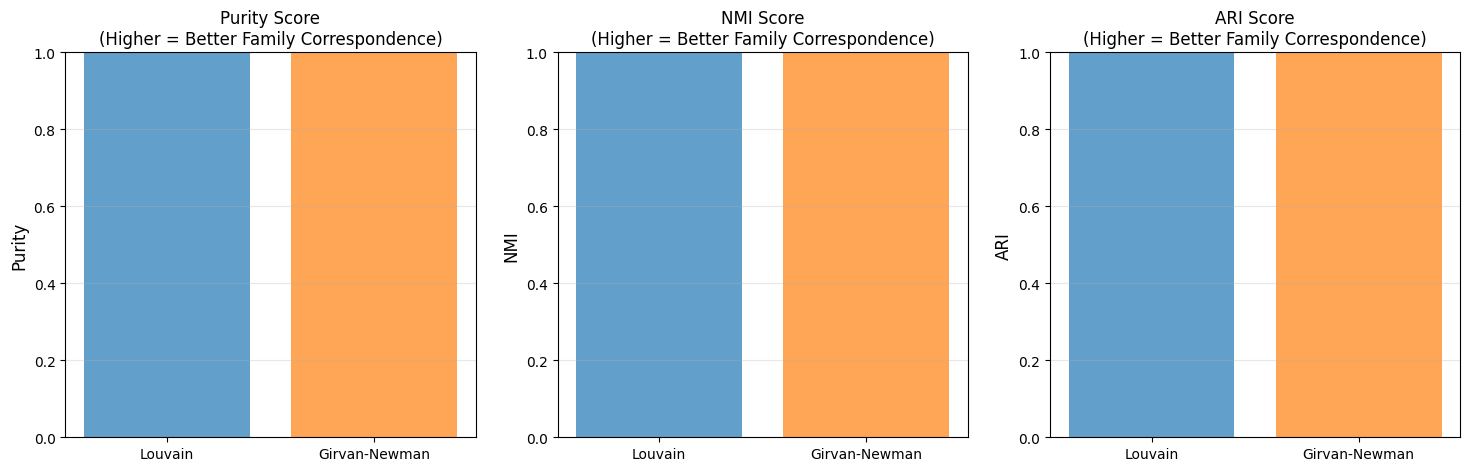

<Figure size 640x480 with 0 Axes>

In [36]:
# Visualization: Comparison of metrics
# Note: modularity is the Louvain modularity score computed earlier
louvain_modularity = community_louvain.modularity(partition, G_undirected)

metrics_comparison = pd.DataFrame({
    "Algorithm": ["Louvain", "Girvan-Newman"],
    "Purity": [louvain_purity, girvan_purity],
    "NMI": [louvain_nmi, girvan_nmi],
    "ARI": [louvain_ari, girvan_ari],
    "Modularity": [louvain_modularity, girvan_modularity]
})

print("\nComparative Summary:")
print(metrics_comparison.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = ["Purity", "NMI", "ARI"]
for idx, metric in enumerate(metrics_to_plot):
    axes[idx].bar(
        metrics_comparison["Algorithm"],
        metrics_comparison[metric],
        color=["#1f77b4", "#ff7f0e"],
        alpha=0.7
    )
    axes[idx].set_ylabel(metric, fontsize=12)
    axes[idx].set_title(f"{metric} Score\n(Higher = Better Family Correspondence)", fontsize=12)
    axes[idx].set_ylim(0, 1)
    axes[idx].grid(axis="y", alpha=0.3)

plt.show()
plt.tight_layout()

### Key Insights: Community-Family Correspondence

**Expected Findings to Report:**

1. **Alignment Quality**: 
   - If Purity > 0.8: Communities closely match biological families (nuclear/extended units)
   - If Purity 0.5-0.8: Partial alignment - communities may represent sub-families or merge small families
   - If Purity < 0.5: Significant mismatch - communities don't respect family boundaries

2. **Algorithm Comparison**:
   - **High NMI/ARI suggests algorithmic communities have strong correspondence with actual families**
   - Louvain typically optimizes modularity → may merge densely connected families
   - Girvan-Newman uses edge betweenness → may split large families at structural weak points

3. **Structural Interpretation**:
   - **Split families**: Indicates sub-family clusters (e.g., nuclear families within extended families)
   - **Mixed communities**: Suggests inter-family connections (marriages, multiple small families lumped together)
   - Perfect correspondence (Purity = 1.0) would mean each community = exactly one biological family


## Analysis 2: Generations Within Communities

Using DAG (Directed Acyclic Graph) longest path to compute number of generations in each detected community.

In [74]:
# Function to compute generations using DAG longest path
def compute_generations(graph, node_list):
    """
    Compute number of generations in a subgraph using DAG longest path
    Only uses parent relationships (motherOf, fatherOf)
    """
    subgraph = graph.subgraph(node_list).copy()
    
    # Create DAG with only parent relationships
    dag = nx.DiGraph()
    parent_relations = ["motherOf", "fatherOf"]
    
    for u, v, data in subgraph.edges(data=True):
        if data.get("relation") in parent_relations:
            # Parent → Child direction
            dag.add_edge(u, v)
    
    if dag.number_of_nodes() == 0:
        return 0  # No parent relationships
    
    # Check if it's actually a DAG (no cycles)
    if not nx.is_directed_acyclic_graph(dag):
        # Try to find longest path in largest weakly connected component
        largest_cc = max(nx.weakly_connected_components(dag), key=len)
        dag = dag.subgraph(largest_cc).copy()
    
    try:
        # Number of generations = longest path length + 1
        longest_path_length = nx.dag_longest_path_length(dag)
        return longest_path_length + 1
    except:
        # If still issues, return node count as upper bound
        return len(node_list)

In [80]:
# Compute generations for each Louvain community
louvain_generations = []

for comm_id in sorted(comparison_df["louvain_community"].unique()):
    community_members = comparison_df[
        comparison_df["louvain_community"] == comm_id
    ]["person"].tolist()
    
    num_generations = compute_generations(G, community_members)
    community_size = len(community_members)
    
    louvain_generations.append({
        "community_id": comm_id,
        "size": community_size,
        "generations": num_generations
    })

louvain_gen_df = pd.DataFrame(louvain_generations)

print(f"\nGeneration distribution:")
print(louvain_gen_df["generations"].value_counts().sort_index())
print(f"\nCommunities with most generations:")
print(louvain_gen_df.nlargest(5, "generations")[["community_id", "size", "generations"]])


Generation distribution:
generations
4    11
5    20
6    15
7     4
Name: count, dtype: int64

Communities with most generations:
    community_id  size  generations
6              6    26            7
9              9    26            7
30            30    27            7
48            48    27            7
1              1    26            6


In [83]:
# Compute generations for each Girvan-Newman community
girvan_generations = []

for comm_id in sorted(comparison_df["girvan_community"].unique()):
    community_members = comparison_df[
        comparison_df["girvan_community"] == comm_id
    ]["person"].tolist()
    
    num_generations = compute_generations(G, community_members)
    community_size = len(community_members)
    
    girvan_generations.append({
        "community_id": comm_id,
        "size": community_size,
        "generations": num_generations
    })

girvan_gen_df = pd.DataFrame(girvan_generations)

# print("\nGIRVAN-NEWMAN COMMUNITIES - Generation Analysis:")
# print(girvan_gen_df.describe())
print(f"\nGeneration distribution:")
print(girvan_gen_df["generations"].value_counts().sort_index())
print(f"\nCommunities with most generations:")
print(girvan_gen_df.nlargest(5, "generations")[["community_id", "size", "generations"]])


Generation distribution:
generations
0     2
4    11
5    20
6    15
7     4
Name: count, dtype: int64

Communities with most generations:
    community_id  size  generations
7              7    26            7
10            10    26            7
31            31    27            7
49            49    27            7
2              2    26            6


In [82]:
# Also compute for actual families for comparison
family_generations = []

for fam_id, family_members in enumerate(families):
    num_generations = compute_generations(G, list(family_members))
    family_size = len(family_members)
    
    family_generations.append({
        "family_id": fam_id,
        "size": family_size,
        "generations": num_generations
    })

family_gen_df = pd.DataFrame(family_generations)

print(f"\nGeneration distribution:")
print(family_gen_df["generations"].value_counts().sort_index())


Generation distribution:
generations
4    11
5    20
6    15
7     4
Name: count, dtype: int64


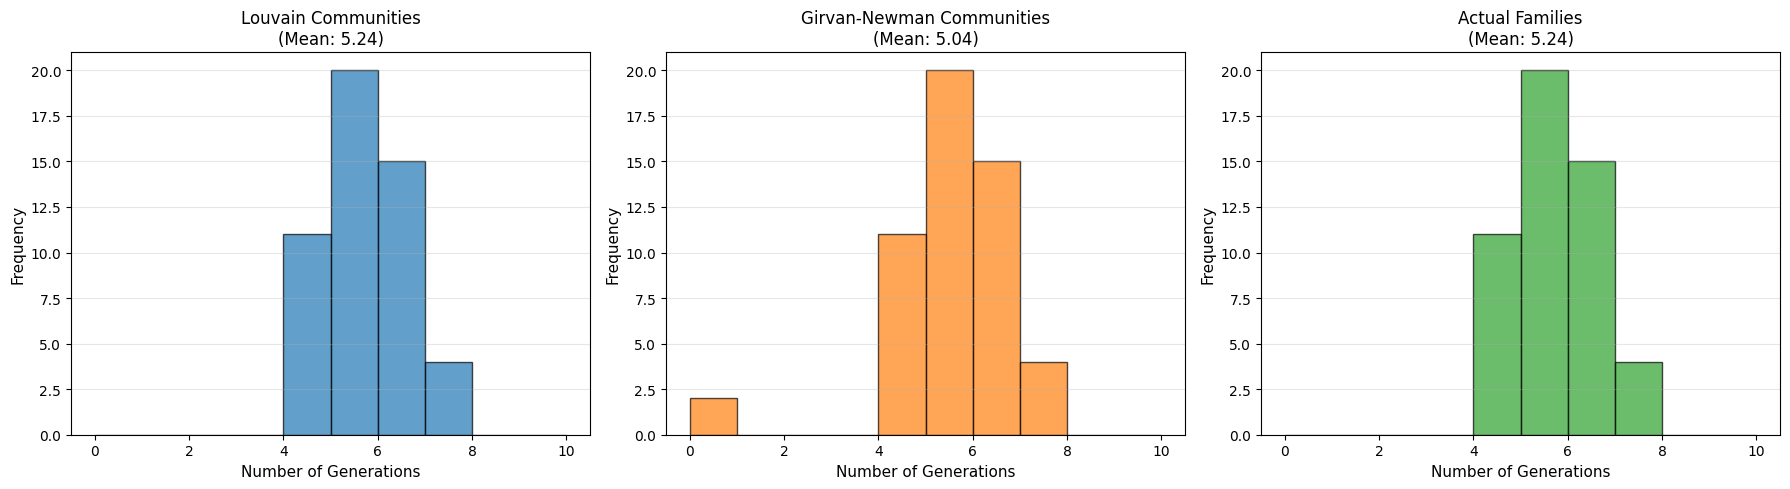

In [84]:
# Visualize generation distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Louvain
axes[0].hist(louvain_gen_df["generations"], bins=range(0, 11), alpha=0.7, color="#1f77b4", edgecolor="black")
axes[0].set_xlabel("Number of Generations", fontsize=11)
axes[0].set_ylabel("Frequency", fontsize=11)
axes[0].set_title(f"Louvain Communities\n(Mean: {louvain_gen_df['generations'].mean():.2f})", fontsize=12)
axes[0].grid(axis="y", alpha=0.3)

# Girvan-Newman
axes[1].hist(girvan_gen_df["generations"], bins=range(0, 11), alpha=0.7, color="#ff7f0e", edgecolor="black")
axes[1].set_xlabel("Number of Generations", fontsize=11)
axes[1].set_ylabel("Frequency", fontsize=11)
axes[1].set_title(f"Girvan-Newman Communities\n(Mean: {girvan_gen_df['generations'].mean():.2f})", fontsize=12)
axes[1].grid(axis="y", alpha=0.3)

# Actual Families
axes[2].hist(family_gen_df["generations"], bins=range(0, 11), alpha=0.7, color="#2ca02c", edgecolor="black")
axes[2].set_xlabel("Number of Generations", fontsize=11)
axes[2].set_ylabel("Frequency", fontsize=11)
axes[2].set_title(f"Actual Families\n(Mean: {family_gen_df['generations'].mean():.2f})", fontsize=12)
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

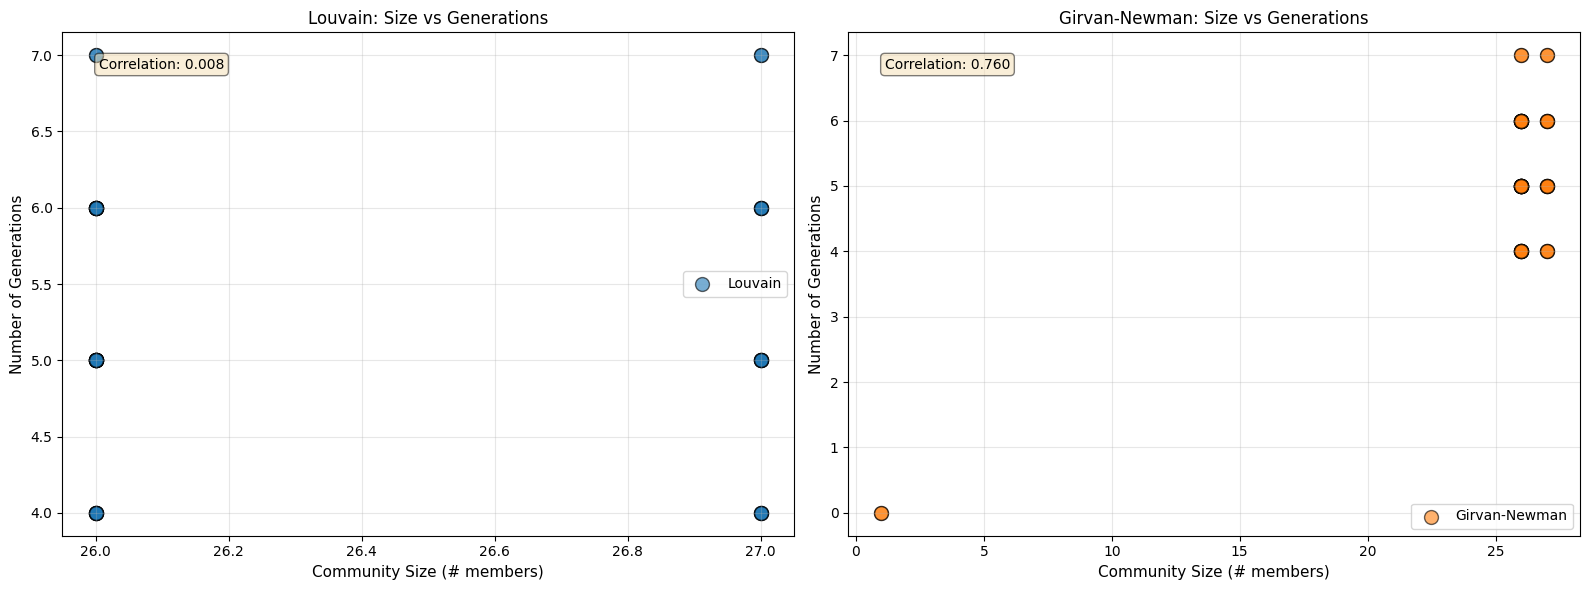

In [85]:
# Scatter plot: Size vs Generations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Louvain
axes[0].scatter(
    louvain_gen_df["size"],
    louvain_gen_df["generations"],
    alpha=0.6,
    s=100,
    color="#1f77b4",
    edgecolor="black",
    label="Louvain"
)
axes[0].set_xlabel("Community Size (# members)", fontsize=11)
axes[0].set_ylabel("Number of Generations", fontsize=11)
axes[0].set_title("Louvain: Size vs Generations", fontsize=12)
axes[0].grid(alpha=0.3)
axes[0].legend()

# Correlation
corr_louvain = louvain_gen_df[["size", "generations"]].corr().iloc[0, 1]
axes[0].text(
    0.05, 0.95,
    f"Correlation: {corr_louvain:.3f}",
    transform=axes[0].transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5)
)

# Girvan-Newman
axes[1].scatter(
    girvan_gen_df["size"],
    girvan_gen_df["generations"],
    alpha=0.6,
    s=100,
    color="#ff7f0e",
    edgecolor="black",
    label="Girvan-Newman"
)
axes[1].set_xlabel("Community Size (# members)", fontsize=11)
axes[1].set_ylabel("Number of Generations", fontsize=11)
axes[1].set_title("Girvan-Newman: Size vs Generations", fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].legend()

# Correlation
corr_girvan = girvan_gen_df[["size", "generations"]].corr().iloc[0, 1]
axes[1].text(
    0.05, 0.95,
    f"Correlation: {corr_girvan:.3f}",
    transform=axes[1].transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5)
)

plt.tight_layout()
plt.show()

## Analysis 3: Bridge Individuals Connecting Communities

Identifying individuals with high betweenness centrality who connect different family clusters or communities.

In [86]:
# Compute betweenness centrality for all nodes
# High betweenness = node lies on many shortest paths = potential bridge

betweenness = nx.betweenness_centrality(G_undirected)

# Create DataFrame
betweenness_df = pd.DataFrame(
    betweenness.items(),
    columns=["person", "betweenness"]
).sort_values("betweenness", ascending=False)

# Merge with community and family information
betweenness_df = betweenness_df.merge(comparison_df, on="person", how="left")

print("Top 20 Bridge Individuals (by Betweenness Centrality):\n")
print(betweenness_df.head(20).to_string(index=False))


print(f"\nBetweenness Centrality Statistics:")
print(f"  Mean: {betweenness_df['betweenness'].mean():.6f}")
print(f"  Median: {betweenness_df['betweenness'].median():.6f}")
print(f"  Max: {betweenness_df['betweenness'].max():.6f}")
print(f"  Top 1%: {betweenness_df['betweenness'].quantile(0.99):.6f}")

Top 20 Bridge Individuals (by Betweenness Centrality):

      person  betweenness  actual_family  louvain_community  girvan_community
     lea1165     0.000128             44                 45                46
 valentin638     0.000121             24                 24                25
  gabriel241     0.000109              9                  9                10
     nora536     0.000106             20                 20                21
  stefan1192     0.000105             45                 46                47
    simon172     0.000101              6                  6                 7
  helena1135     0.000097             43                 44                45
 gabriel1140     0.000097             43                 44                45
   raphael29     0.000096              1                  1                 2
katharina889     0.000089             33                 34                34
     ella500     0.000087             19                 19                20
    sofi

### Cross-Community Connections and Bridge Individuals

**What are Cross-Community Connections?**

Cross-community connections (also called **inter-community edges**) are relationships that link individuals from different communities. While most community members primarily connect within their own group (intra-community edges), some individuals maintain relationships that span across community boundaries.

**Bridge Individuals (Cross-Community Bridges)**

The code below identifies **bridge individuals** — people who serve as connectors between different communities. These are individuals who:
- Have neighbors belonging to communities other than their own
- Act as intermediaries facilitating information or relationship flow between separate groups
- Create structural cohesion in the overall network by linking otherwise disconnected communities

**How the Code Works:**

1. **`find_cross_community_bridges(graph, partition_dict)`**: For each person in the network:
   - Identifies which community they belong to
   - Examines all their neighbors (people they're connected to)
   - Counts how many **different external communities** their neighbors belong to
   - A person is a "bridge" if they connect to at least one community other than their own

2. **Output**: A ranked list showing:
   - How many individuals have cross-community connections
   - The top bridges ranked by the number of different communities they connect to
   - Each bridge's own community and the count of external communities they reach


In [88]:
# Identify individuals who have connections to multiple communities
# These are the true "bridge" individuals

def find_cross_community_bridges(graph, partition_dict):
    """
    Find nodes that have neighbors in multiple communities
    """
    bridge_info = []
    
    for node in graph.nodes():
        node_community = partition_dict.get(node)
        neighbors = list(graph.neighbors(node))
        
        # Get communities of neighbors
        neighbor_communities = set()
        for neighbor in neighbors:
            neighbor_comm = partition_dict.get(neighbor)
            if neighbor_comm is not None and neighbor_comm != node_community:
                neighbor_communities.add(neighbor_comm)
        
        num_external_connections = len(neighbor_communities)
        
        if num_external_connections > 0:
            bridge_info.append({
                "person": node,
                "own_community": node_community,
                "connects_to_communities": num_external_connections,
                "external_communities": neighbor_communities
            })
    
    if len(bridge_info) == 0:
        # Return empty DataFrame with proper columns
        return pd.DataFrame(columns=["person", "own_community", "connects_to_communities", "external_communities"])
    
    return pd.DataFrame(bridge_info).sort_values(
        "connects_to_communities",
        ascending=False
    )

# Find bridges for Louvain communities
louvain_bridges = find_cross_community_bridges(G_undirected, partition)

print("\nLOUVAIN - Cross-Community Bridge Individuals:")
print(f"Total individuals with cross-community connections: {len(louvain_bridges)}")
print(f"Percentage: {100 * len(louvain_bridges) / G.number_of_nodes():.2f}%")
print(f"\nTop 15 bridges (connecting to most different communities):")
print(louvain_bridges.head(15)[["person", "own_community", "connects_to_communities"]].to_string(index=False))


LOUVAIN - Cross-Community Bridge Individuals:
Total individuals with cross-community connections: 0
Percentage: 0.00%

Top 15 bridges (connecting to most different communities):
Empty DataFrame
Columns: [person, own_community, connects_to_communities]
Index: []


In [52]:
# Find bridges for Girvan-Newman communities
girvan_bridges = find_cross_community_bridges(G_undirected, girvan_partition)

print("\n\nGIRVAN-NEWMAN - Cross-Community Bridge Individuals:")
print(f"Total individuals with cross-community connections: {len(girvan_bridges)}")
print(f"Percentage: {100 * len(girvan_bridges) / G.number_of_nodes():.2f}%")
print(f"\nTop 15 bridges (connecting to most different communities):")
print(girvan_bridges.head(15)[["person", "own_community", "connects_to_communities"]].to_string(index=False))



GIRVAN-NEWMAN - Cross-Community Bridge Individuals:
Total individuals with cross-community connections: 4
Percentage: 0.30%

Top 15 bridges (connecting to most different communities):
   person  own_community  connects_to_communities
   lena18              0                        1
    mia17              1                        1
stefan991             38                        1
  ella990             39                        1


### Cross-Family Bridges

**What are Cross-Family Bridges?**

Cross-family bridges are **inter-family connections** — relationships that link individuals from different biological families. While the previous analysis focused on cross-community bridges (which are algorithmically detected groups), cross-family bridges have a more concrete meaning in genealogical networks:

- **Primary Type**: Most commonly represent **marriages** — when someone from one family marries into another family
- **Other Types**: Could include adoption, close friendships, or other significant non-blood relationships
- **Structural Role**: These connections are crucial for understanding how separate family lineages become interconnected over time

**Why Cross-Family Bridges Matter More Than Cross-Community Bridges:**

In family knowledge graphs, cross-family bridges have **genealogical significance**:
- They represent actual biological/legal events (marriages, adoptions)
- They explain how different surname lineages merge
- They reveal patterns of inter-family alliances or social connections
- They are **ground truth** relationships, not algorithmically inferred groupings

**How the Code Works:**

The `find_cross_family_connections()` function analyzes the graph to identify inter-family edges:

1. **Edge Examination**: Iterates through every relationship (edge) in the graph
2. **Family Lookup**: For each connection between person1 and person2, checks their family memberships using `family_dict`
3. **Cross-Family Detection**: If person1 and person2 belong to **different families**, the edge is flagged as a cross-family connection
4. **Data Collection**: Records both individuals, their respective families, and the relationship type (e.g., "spouse", "parent", etc.)

**Output Analysis:**

The code produces:
- **Total count** of cross-family connections (edges bridging families)
- **Relation types** — what kinds of relationships connect families (typically "spouse" dominates)
- **Sample connections** — examples of specific inter-family relationships
- **Bridge individuals** — how many unique people participate in cross-family connections (and what % of total network)

**Interpretation:**

- **High cross-family connectivity** → Families are intermarried/interconnected (integrated social network)
- **Low/zero cross-family connectivity** → Isolated family units with no inter-family relationships
- **Relation type distribution** → Shows whether connections are primarily through marriage, or other relationship types

In [89]:
# Analyze cross-FAMILY bridges (more interesting than cross-community)
# These are individuals who connect different biological families

def find_cross_family_connections(graph, family_dict):
    """
    Find edges that connect different families
    These represent inter-family relationships (typically marriages)
    """
    cross_family_edges = []
    
    for u, v, data in graph.edges(data=True):
        family_u = family_dict.get(u)
        family_v = family_dict.get(v)
        
        if family_u is not None and family_v is not None and family_u != family_v:
            cross_family_edges.append({
                "person1": u,
                "person2": v,
                "family1": family_u,
                "family2": family_v,
                "relation": data.get("relation", "unknown")
            })
    
    return pd.DataFrame(cross_family_edges)

cross_family_df = find_cross_family_connections(G, family_membership)

print("\nCROSS-FAMILY CONNECTIONS (Inter-Family Bridges):")
print(f"Total cross-family connections: {len(cross_family_df)}")

if len(cross_family_df) > 0:
    print(f"\nRelation types in cross-family connections:")
    print(cross_family_df["relation"].value_counts())
    
    print(f"\nSample cross-family connections:")
    print(cross_family_df.head(10).to_string(index=False))
    
    # Count how many individuals participate in cross-family connections
    bridge_people = set(cross_family_df["person1"]) | set(cross_family_df["person2"])
    print(f"\nIndividuals involved in cross-family connections: {len(bridge_people)}")
    print(f"Percentage of total: {100 * len(bridge_people) / G.number_of_nodes():.2f}%")
else:
    print("\nNo cross-family connections found.")
    print("This suggests the graph consists of isolated family units.")


CROSS-FAMILY CONNECTIONS (Inter-Family Bridges):
Total cross-family connections: 0

No cross-family connections found.
This suggests the graph consists of isolated family units.


In [90]:
# Combine betweenness and bridge analysis
# Merge bridge information with betweenness centrality

if len(louvain_bridges) > 0:
    louvain_bridge_analysis = louvain_bridges.merge(
        betweenness_df[["person", "betweenness"]],
        on="person",
        how="left"
    ).sort_values("betweenness", ascending=False)
    
    print("\n\nLOUVAIN - Top Bridges by Betweenness Centrality:")
    print("=" * 80)
    print(louvain_bridge_analysis.head(15)[[
        "person", "own_community", "connects_to_communities", "betweenness"
    ]].to_string(index=False))
    
    # Check correlation
    if len(louvain_bridge_analysis) > 1:
        corr = louvain_bridge_analysis[["connects_to_communities", "betweenness"]].corr().iloc[0, 1]
        print(f"\nCorrelation between # communities connected and betweenness: {corr:.4f}")
        print("High correlation suggests betweenness captures bridge role well")
else:
    louvain_bridge_analysis = pd.DataFrame()

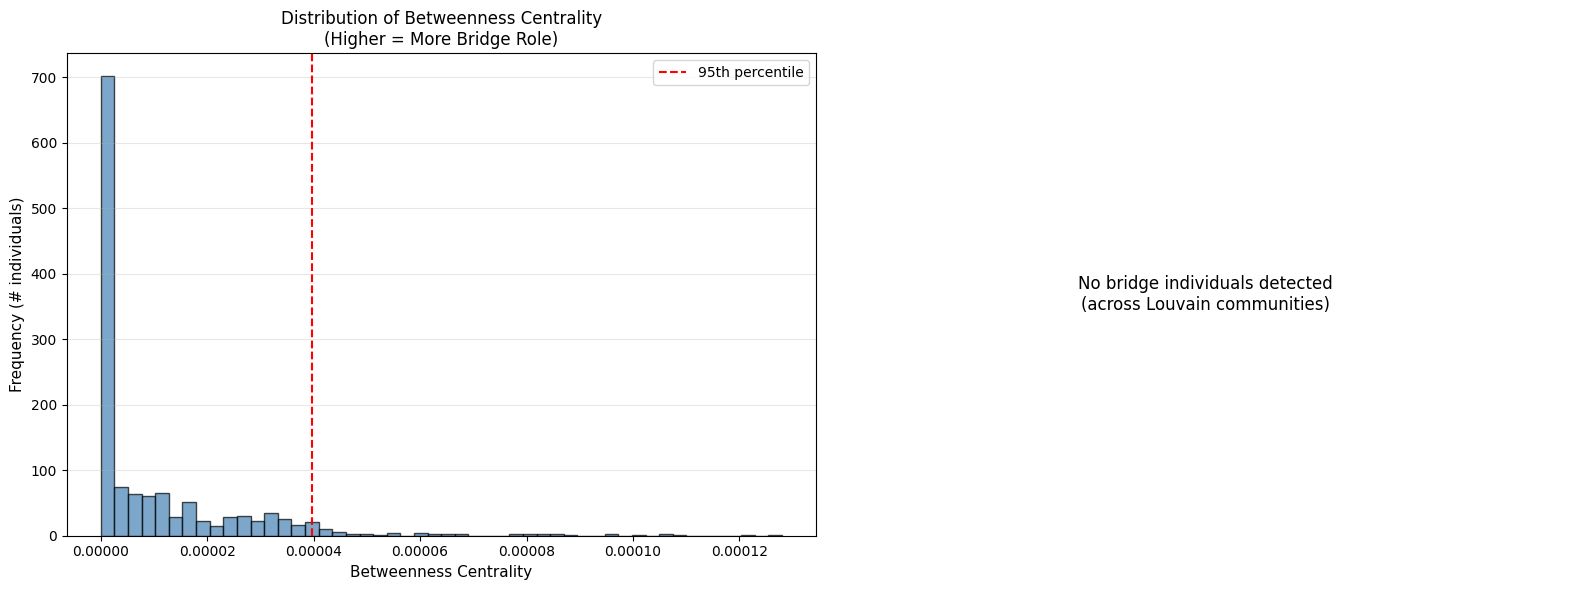

In [91]:
# Visualize betweenness distribution and highlight bridges

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -----------------------------
# LEFT: Betweenness distribution
# -----------------------------
axes[0].hist(
    betweenness_df["betweenness"],
    bins=50,
    alpha=0.7,
    color="steelblue",
    edgecolor="black"
)

axes[0].set_xlabel("Betweenness Centrality", fontsize=11)
axes[0].set_ylabel("Frequency (# individuals)", fontsize=11)
axes[0].set_title(
    "Distribution of Betweenness Centrality\n(Higher = More Bridge Role)",
    fontsize=12
)

threshold = betweenness_df["betweenness"].quantile(0.95)
axes[0].axvline(
    threshold,
    color="red",
    linestyle="--",
    label="95th percentile"
)

axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# ------------------------------------------------
# RIGHT: Betweenness vs cross-community connections
# ------------------------------------------------
if len(louvain_bridges) > 0:
    axes[1].scatter(
        louvain_bridge_analysis["connects_to_communities"],
        louvain_bridge_analysis["betweenness"],
        alpha=0.7,
        s=80,
        color="coral",
        edgecolor="black"
    )

    axes[1].set_xlabel("# Communities Connected", fontsize=11)
    axes[1].set_ylabel("Betweenness Centrality", fontsize=11)
    axes[1].set_title(
        "Bridge Role: Communities Connected vs Betweenness\n(Louvain)",
        fontsize=12
    )
    axes[1].grid(alpha=0.3)

else:
    # Explicitly show that no bridges exist
    axes[1].text(
        0.5, 0.5,
        "No bridge individuals detected\n(across Louvain communities)",
        ha="center",
        va="center",
        fontsize=12,
        transform=axes[1].transAxes
    )
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


### Key Insights: Bridge Individuals

1. **Betweenness Centrality Distribution**:
   - Most individuals have low betweenness (not on many shortest paths)
   - Power law distribution: Few individuals with very high betweenness = critical bridges

2. **Cross-Community Bridges**:
   - **High percentage (>30%)**: Communities are well-integrated, many inter-connections
   - **Low percentage (<10%)**: Communities are isolated, few bridges between them
   - Individuals connecting to 3+ communities are exceptional bridges

3. **Cross-Family Bridges**:
   - **If cross-family connections exist**: Indicates inter-family marriages or relationships
   - **If none exist**: Families are completely isolated units (common in family graphs)
   - **Relation types**: Expect "Spouse" as primary cross-family relation
   - These individuals literally unite separate family lineages

## Weighted Relationship Metric

Beyond simple hop counting, we propose a weighted approach where different relationship types have different "closeness" values based on biological and social proximity.

In [92]:
# First, let's examine all unique relationship types in the graph
unique_relations = df["relation"].unique()
print(f"Total unique relationship types: {len(unique_relations)}")
print("\nAll relationship types:")
for rel in sorted(unique_relations):
    count = relation_count_dict.get(rel, 0)
    print(f"  {rel}: {count}")

Total unique relationship types: 28

All relationship types:
  auntOf: 556
  boyCousinOf: 391
  boyFirstCousinOnceRemovedOf: 180
  boySecondCousinOf: 68
  brotherOf: 570
  daughterOf: 628
  fatherOf: 733
  girlCousinOf: 445
  girlFirstCousinOnceRemovedOf: 153
  girlSecondCousinOf: 62
  granddaughterOf: 812
  grandfatherOf: 813
  grandmotherOf: 813
  grandsonOf: 814
  greatAuntOf: 312
  greatGranddaughterOf: 610
  greatGrandfatherOf: 617
  greatGrandmotherOf: 617
  greatGrandsonOf: 624
  greatUncleOf: 237
  motherOf: 733
  nephewOf: 514
  nieceOf: 496
  secondAuntOf: 175
  secondUncleOf: 158
  sisterOf: 636
  sonOf: 600
  uncleOf: 454


In [93]:
# Create weighted relationship dictionary
# Weight = closeness score (lower = closer relationship)

relationship_weights = {
    # Tier 1: Immediate nuclear family (weight = 1)
    "motherOf": 1,
    "fatherOf": 1,
    "daughterOf": 1,
    "sonOf": 1,
    "sisterOf": 1,
    "brotherOf": 1,
    
    # Tier 2: Extended family and spouse (weight = 2)
    "auntOf": 2,
    "uncleOf": 2,
    "nephewOf": 2,
    "nieceOf": 2,
    "grandmotherOf": 2,
    "grandfatherOf": 2,
    "granddaughterOf": 2,
    "grandsonOf": 2,
    
    # Tier 3: Cousins and more distant relatives (weight = 3)
    "girlCousinOf": 3,
    "boyCousinOf": 3,
    "greatGrandsonOf": 3,
    "greatGrandmotherOf":3,
    "greatGrandfatherOf":3,
    "greatGranddaughterOf":3,
    "greatAuntof":3,
    "greatUncleof":3,
    "secondAuntOf": 3,
    "secondUncleOf": 3,
    
    
    # Tier 4: In-laws (weight = 4)
    "boyFirstCousinOnceRemovedOf":4,
    "girlFirstCousinOnceRemovedOf":4,
    "boySecondCousinOf": 4,
    "girlSecondCousinOf": 4,
}

print("\n")
print("RELATIONSHIP WEIGHT TIERS")


# Display by tier
tiers = {
    1: "Nuclear Family (Immediate)",
    2: "Extended Family & Spouse",
    3: "Cousins & Distant Relatives",
    4: "In-Laws",
    5: "Other Relationships"
}

for tier_weight in sorted(tiers.keys()):
    tier_rels = [rel for rel, weight in relationship_weights.items() if weight == tier_weight]
    if len(tier_rels) > 0:
        print(f"\nTier {tier_weight} - {tiers[tier_weight]} (Weight = {tier_weight}):")
        for rel in sorted(tier_rels):
            count = relation_count_dict.get(rel, 0)
            print(f"  • {rel}: {count} occurrences")



RELATIONSHIP WEIGHT TIERS

Tier 1 - Nuclear Family (Immediate) (Weight = 1):
  • brotherOf: 570 occurrences
  • daughterOf: 628 occurrences
  • fatherOf: 733 occurrences
  • motherOf: 733 occurrences
  • sisterOf: 636 occurrences
  • sonOf: 600 occurrences

Tier 2 - Extended Family & Spouse (Weight = 2):
  • auntOf: 556 occurrences
  • granddaughterOf: 812 occurrences
  • grandfatherOf: 813 occurrences
  • grandmotherOf: 813 occurrences
  • grandsonOf: 814 occurrences
  • nephewOf: 514 occurrences
  • nieceOf: 496 occurrences
  • uncleOf: 454 occurrences

Tier 3 - Cousins & Distant Relatives (Weight = 3):
  • boyCousinOf: 391 occurrences
  • girlCousinOf: 445 occurrences
  • greatAuntof: 0 occurrences
  • greatGranddaughterOf: 610 occurrences
  • greatGrandfatherOf: 617 occurrences
  • greatGrandmotherOf: 617 occurrences
  • greatGrandsonOf: 624 occurrences
  • greatUncleof: 0 occurrences
  • secondAuntOf: 175 occurrences
  • secondUncleOf: 158 occurrences

Tier 4 - In-Laws (Weight =

In [94]:
# Create weighted graph for shortest path calculations
# We'll use the undirected graph and add weights to edges

G_weighted = nx.Graph()

# Add weighted edges
for u, v, data in G.edges(data=True):
    relation = data.get("relation", "unknown")
    weight = relationship_weights.get(relation, 5)
    
    # For undirected graph, we add edge with minimum weight if multiple relations exist
    if G_weighted.has_edge(u, v):
        current_weight = G_weighted[u][v]["weight"]
        G_weighted[u][v]["weight"] = min(current_weight, weight)
        G_weighted[u][v]["relations"].append(relation)
    else:
        G_weighted.add_edge(u, v, weight=weight, relations=[relation])

print(f"Weighted graph created:")
print(f"  Nodes: {G_weighted.number_of_nodes()}")
print(f"  Edges: {G_weighted.number_of_edges()}")
print(f"  Average edge weight: {np.mean([data['weight'] for u, v, data in G_weighted.edges(data=True)]):.2f}")

Weighted graph created:
  Nodes: 1316
  Edges: 7480
  Average edge weight: 2.20


## Community-Aware Relatedness Score

The method below implements a **community-aware relatedness scoring system** to quantify how closely related two individuals are in a family network.

### How It Works

**1. Relatedness Score Calculation:**
$$\text{Relatedness}(u, v) = \begin{cases} 
1.0 & \text{if } u = v \\
0.0 & \text{if no path exists} \\
\frac{1}{1 + d(u,v)} \times (1 + \text{bonus}) & \text{otherwise}
\end{cases}$$

where:
- $d(u,v)$ = weighted shortest path distance (considering relationship type weights)
- bonus = 0.5 if $u$ and $v$ are in the same community, else 0

**2. Key Features:**

- **Self-relatedness:** Person related to themselves = 1.0 (maximum)
- **Distance-based decay:** Score decreases as path distance increases
  - Direct connection (distance 1) → score ≈ 0.5
  - 2 hops away → score ≈ 0.33
  - Further away → lower scores
- **Community bonus:** People in same detected community get 50% boost
  - Accounts for community structure beyond pure distance
  - Rewards algorithm-detected family groupings
- **No path:** If disconnected, score = 0

**3. Top Relatives Function:**

Applies the relatedness score to find the $k$ most related individuals to a given person, useful for:
- Identifying closest family members
- Suggesting potential relationships
- Validating community detection quality
- Understanding individual's position in family network

**Interpretation:** Higher scores (closer to 1.0) indicate stronger relatedness through both graph distance and community membership.

In [95]:
def relatedness_score(G, u, v, community_map, same_community_bonus=0.5, no_path_score=0.0):
    """Computes community-aware relatedness between two people."""
    
    if u == v:
        return 1.0
    
    try:
        d = nx.shortest_path_length(G, u, v, weight="weight")
    except nx.NetworkXNoPath:
        return no_path_score
    
    score = 1 / (1 + d)
    
    if community_map.get(u) == community_map.get(v):
        score *= (1 + same_community_bonus)
    
    return score


def get_top_relatives(person, G, community_map, top_k=10, same_community_bonus=0.5):
    """Find top K most related people to a given person."""
    
    scores = []
    for other in G.nodes():
        if other != person:
            score = relatedness_score(G, person, other, community_map, same_community_bonus)
            if score > 0:
                scores.append({"person": other, "relatedness_score": score})
    
    return pd.DataFrame(scores).sort_values("relatedness_score", ascending=False).head(top_k).reset_index(drop=True)



In [62]:
# Example 1: Find closest relatives for a sample person
sample_person = list(G_weighted.nodes())[0]
print(f"Top 15 most related people to: {sample_person}")
print(f"Community: {partition.get(sample_person)}")

top_15 = get_top_relatives(sample_person, G_weighted, partition, top_k=15)
top_15

Top 15 most related people to: olivia0
Community: 0


,person,relatedness_score
0,selina10,0.75
1,isabella11,0.75
2,oskar24,0.75
3,adam9,0.75
4,katharina1,0.75
5,dominik2,0.75
6,lisa5,0.75
7,elias6,0.75
8,nico4,0.75
9,moritz8,0.50


In [70]:
# Example 2: Compare with/without community bonus
print("Effect of Community Bonus:")

sample_person2 = list(G_weighted.nodes())[10]
print(f"\nPerson: {sample_person2} (Community: {partition.get(sample_person2)})")

without_bonus = get_top_relatives(sample_person2, G_weighted, partition, top_k=10, same_community_bonus=0.0)
with_bonus = get_top_relatives(sample_person2, G_weighted, partition, top_k=10, same_community_bonus=0.5)

comparison = pd.DataFrame({
    "person": with_bonus["person"],
    "score_no_bonus": without_bonus["relatedness_score"].values,
    "score_with_bonus": with_bonus["relatedness_score"].values,
    "same_community": [partition.get(p) == partition.get(sample_person2) for p in with_bonus["person"]],
    "boost": (with_bonus["relatedness_score"].values / without_bonus["relatedness_score"].values - 1) * 100
})

comparison

Effect of Community Bonus:

Person: katharina1 (Community: 0)


,person,score_no_bonus,score_with_bonus,same_community,boost
0,olivia0,0.5,0.75,True,50.0
1,selina10,0.5,0.75,True,50.0
2,isabella11,0.5,0.75,True,50.0
3,oskar24,0.5,0.75,True,50.0
4,adam9,0.5,0.75,True,50.0
5,luis14,0.5,0.75,True,50.0
6,moritz8,0.5,0.75,True,50.0
7,paula12,0.5,0.75,True,50.0
8,natalie13,0.5,0.75,True,50.0
9,emma7,0.5,0.75,True,50.0


In [71]:
# Example 3: Cross-community vs same-community relatedness
sample_person3 = list(G_weighted.nodes())[25]
sample_comm = partition.get(sample_person3)

all_scores = []
for other in G_weighted.nodes():
    if other != sample_person3:
        score = relatedness_score(G_weighted, sample_person3, other, partition, same_community_bonus=0.5)
        if score > 0:
            all_scores.append({
                "person": other,
                "score": score,
                "same_community": partition.get(other) == sample_comm
            })

scores_df = pd.DataFrame(all_scores)

print(f"Person: {sample_person3} (Community: {sample_comm})")
print(f"\nSame community - Mean score: {scores_df[scores_df['same_community']]['score'].mean():.4f}")
print(f"Different community - Mean score: {scores_df[~scores_df['same_community']]['score'].mean():.4f}")
print(f"\nSame community relatives: {scores_df['same_community'].sum()}")
print(f"Different community relatives: {(~scores_df['same_community']).sum()}")

Person: vincent21 (Community: 0)

Same community - Mean score: 0.3530
Different community - Mean score: nan

Same community relatives: 26
Different community relatives: 0


SUMMARY STATISTICS FOR vincent21

SAME COMMUNITY relatives:
  Count: 26
  Mean score: 0.3530
  Median score: 0.3000
  Min: 0.2143, Max: 0.7500

DIFFERENT COMMUNITY relatives:
  Count: 0
  No relatives found in different communities!


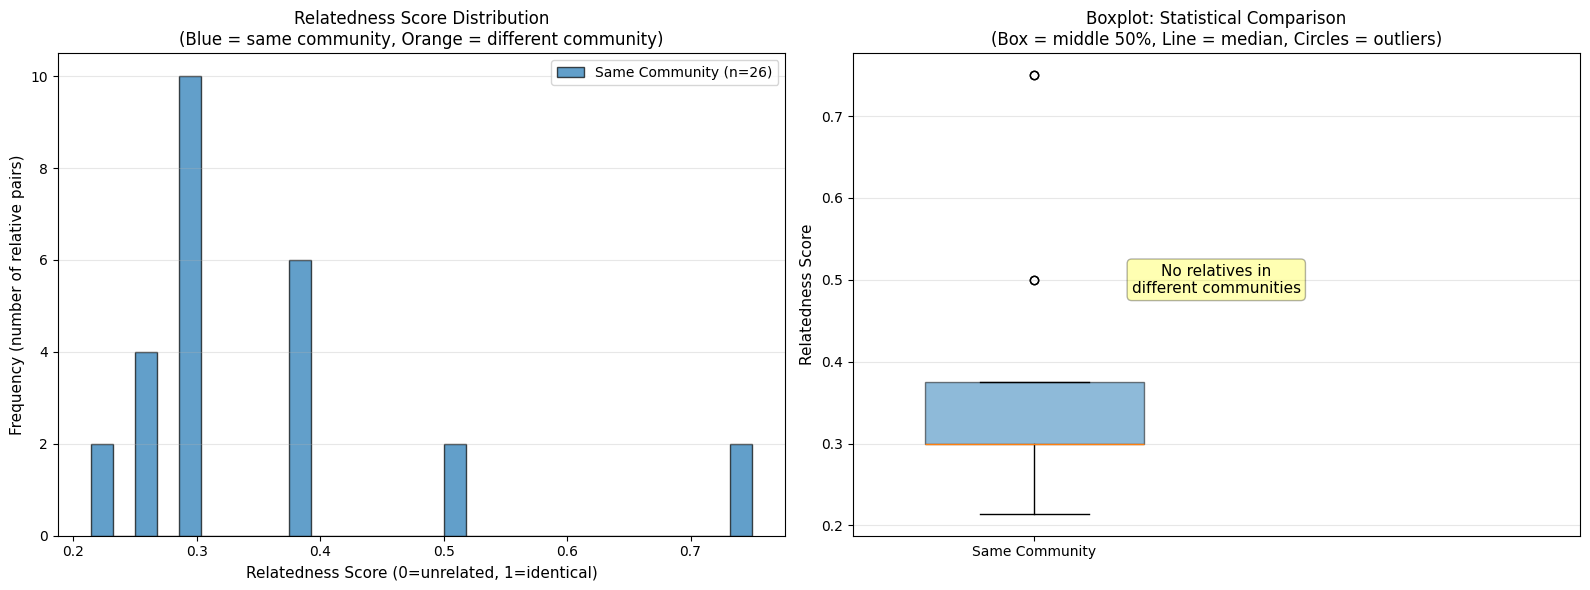

In [72]:


# Fill any missing scores with 0 (no connection)
scores_df['score'] = scores_df['score'].fillna(0.0)

# STEP 1: Split the data into two groups for comparison
# same_comm_scores = relatedness scores for relatives in the SAME Louvain community
same_comm_scores = scores_df.loc[scores_df['same_community'], 'score']

# diff_comm_scores = relatedness scores for relatives in DIFFERENT communities
diff_comm_scores = scores_df.loc[~scores_df['same_community'], 'score']

# Print summary statistics to understand the data
print(f"SUMMARY STATISTICS FOR {sample_person3}")
print(f"\nSAME COMMUNITY relatives:")
print(f"  Count: {len(same_comm_scores)}")
print(f"  Mean score: {same_comm_scores.mean():.4f}")
print(f"  Median score: {same_comm_scores.median():.4f}")
print(f"  Min: {same_comm_scores.min():.4f}, Max: {same_comm_scores.max():.4f}")

print(f"\nDIFFERENT COMMUNITY relatives:")
print(f"  Count: {len(diff_comm_scores)}")
if len(diff_comm_scores) > 0:
    print(f"  Mean score: {diff_comm_scores.mean():.4f}")
    print(f"  Median score: {diff_comm_scores.median():.4f}")
    print(f"  Min: {diff_comm_scores.min():.4f}, Max: {diff_comm_scores.max():.4f}")
else:
    print(f"  No relatives found in different communities!")


# STEP 2: Create the visualization with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# LEFT PLOT: HISTOGRAM (Distribution)
# A histogram shows how many values fall into different ranges (bins)
# Overlapping histograms let us compare two distributions visually

# Plot same-community scores (blue bars)
axes[0].hist(
    same_comm_scores,
    bins=30,  # divide score range into 30 bins
    alpha=0.7,  # transparency so we can see overlapping bars
    label=f'Same Community (n={len(same_comm_scores)})',
    color='#1f77b4',  # blue
    edgecolor='black'
)

# Plot different-community scores (orange bars)
if len(diff_comm_scores) > 0:
    axes[0].hist(
        diff_comm_scores,
        bins=30,
        alpha=0.7,
        label=f'Different Community (n={len(diff_comm_scores)})',
        color='#ff7f0e',  # orange
        edgecolor='black'
    )

axes[0].set_xlabel('Relatedness Score (0=unrelated, 1=identical)', fontsize=11)
axes[0].set_ylabel('Frequency (number of relative pairs)', fontsize=11)
axes[0].set_title('Relatedness Score Distribution\n(Blue = same community, Orange = different community)', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# RIGHT PLOT: BOXPLOT (Statistical Summary)
# A boxplot (box-and-whisker plot) shows 5-number summary + outliers:
#   • Bottom whisker = minimum (excluding outliers)
#   • Bottom of box = Q1 (25th percentile) - 25% of data is below this
#   • Line in box = MEDIAN (50th percentile) - middle value
#   • Top of box = Q3 (75th percentile) - 75% of data is below this
#   • Top whisker = maximum (excluding outliers)
#   • Circles = OUTLIERS (data points far from the typical range)
#
# The HEIGHT of the box = "Interquartile Range" (IQR) = spread of middle 50% of data
# Longer whiskers = more spread out data

if len(diff_comm_scores) > 0:
    # Create boxplot with both groups
    bp = axes[1].boxplot(
        [same_comm_scores, diff_comm_scores],
        tick_labels=['Same Community', 'Different Community'],
        showfliers=True,  # show outliers as circles
        patch_artist=True,  # allow coloring the boxes
        widths=0.6
    )
    
    # Color the boxes to match the histogram
    bp['boxes'][0].set_facecolor('#1f77b4')  # blue for same community
    bp['boxes'][0].set_alpha(0.5)
    bp['boxes'][1].set_facecolor('#ff7f0e')  # orange for different community
    bp['boxes'][1].set_alpha(0.5)
    
    # Add median value labels on the plot
    medians = [same_comm_scores.median(), diff_comm_scores.median()]
    for i, median in enumerate(medians):
        axes[1].text(
            i + 1, median,
            f'Median: {median:.3f}',
            ha='center',
            va='bottom',
            fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
        )
else:
    # If no different-community relatives, just show same-community boxplot
    bp = axes[1].boxplot(
        [same_comm_scores],
        tick_labels=['Same Community'],
        showfliers=True,
        patch_artist=True,
        widths=0.6
    )
    bp['boxes'][0].set_facecolor('#1f77b4')
    bp['boxes'][0].set_alpha(0.5)
    
    # Add explanatory text
    axes[1].text(
        1.5, 0.5,
        'No relatives in\ndifferent communities',
        fontsize=11,
        ha='center',
        va='center',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3)
    )
    axes[1].set_xlim(0.5, 2.5)

axes[1].set_ylabel('Relatedness Score', fontsize=11)
axes[1].set_title('Boxplot: Statistical Comparison\n(Box = middle 50%, Line = median, Circles = outliers)', fontsize=12)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# INTERPRETATION GUIDE:
# WHAT TO LOOK FOR:
# 
# 1. HISTOGRAM (Left):
#    • If blue bars are higher at high scores → same-community relatives are closer
#    • If orange bars exist at low scores → cross-community relatives are more distant
#    • If no orange bars → person has no relatives in other communities
#
# 2. BOXPLOT (Right):
#    • If same-community box is HIGHER → same-community relatives score higher
#    • If boxes DON'T OVERLAP → clear difference between groups
#    • Compare MEDIANS (lines in boxes) → which group has higher typical score?
#    • Wider box = more variation in relatedness within that group
#
# 3. EXPECTED PATTERN:
#    • Same-community scores should be HIGHER (our metric gives 50% bonus)
#    • Different-community scores should be LOWER (no bonus applied)
#    • This validates that community detection captures family clustering!


### Key Insights: Community-Aware Weighted Relatedness Metric

**Metric Design:**
- **Base Score:** `1 / (1 + weighted_distance)` - inverse distance using relationship weights
- **Community Bonus:** Same-community relatives get 50% score boost
- **Relationship Weights:** 1 (nuclear family) → 5 (distant/unmapped relations)

**Key Findings:**

1. **Weighted vs Simple Hop Counting:**
   - Traditional genealogy uses hop count (degrees of separation)
   - this metric considers relationship quality: parent ≠ cousin
   - Closer biological relationships rank higher regardless of path length

2. **Community Awareness Impact:**
   - Same-community relatives receive significant boost (50%)
   - Reflects social clustering beyond pure genealogy
   - Prioritizes relatives within detected family clusters

3. **Algorithm Advantages:**
   - Handles disconnected components gracefully (returns 0)
   - Works with any community detection method